Lendo o arquivo real: result_d2.csv...
-> Matriz gerada com sucesso! Formato: 40 instâncias x 10 algoritmos.


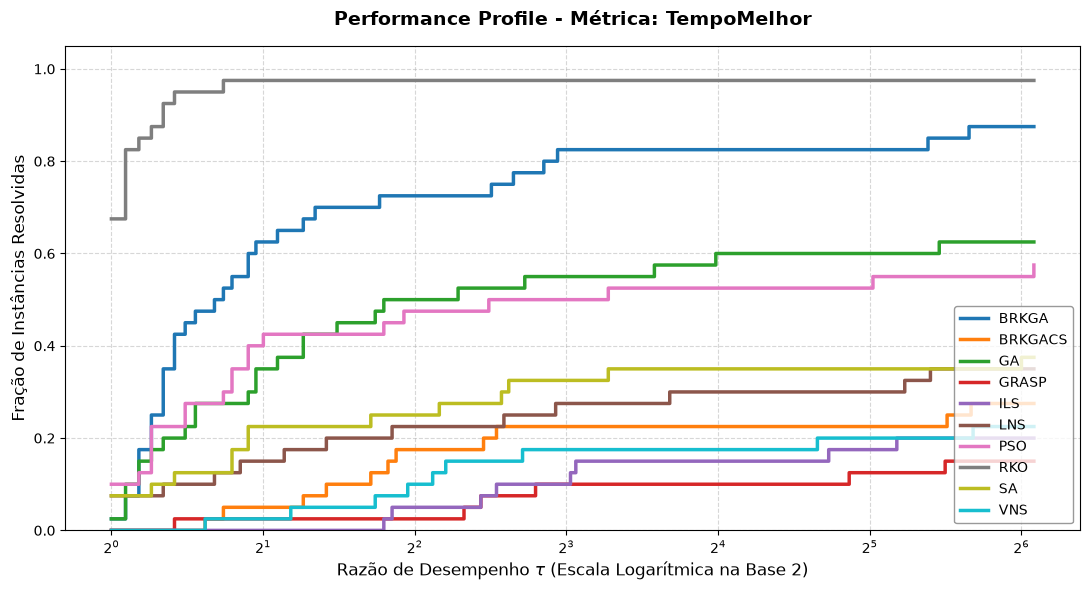

In [1]:
# PERFORMANCE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

def plot_performance_profile(data, title_metric):
    data = data.apply(pd.to_numeric, errors='coerce')
    data.fillna(np.inf, inplace=True)
    min_values = data.min(axis=1)
    r = data.divide(min_values, axis=0)

    plt.figure(figsize=(11, 6))
    n_instances = len(data)

    max_tau = r.replace(np.inf, np.nan).max().max()
    if np.isnan(max_tau) or max_tau == 1.0:
        max_tau = 2.0

    taus = np.linspace(1, max_tau, 1000)


    for col in data.columns:
        y = [sum(r[col] <= t) / n_instances for t in taus]
        plt.step(taus, y, label=col, where='post', lw=2.5)

    plt.xscale('log', base=2)

    plt.xlabel(r'Razão de Desempenho $\tau$ (Escala Logarítmica na Base 2)', fontsize=12)
    plt.ylabel('Fração de Instâncias Resolvidas', fontsize=12)
    plt.title(f'Performance Profile - Métrica: {title_metric}', fontsize=14, fontweight='bold', pad=15)
    plt.grid(True, which="both", ls="--", alpha=0.5)


    plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gray')
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# Leitura
NOME_DO_ARQUIVO = "result_d2.csv"

print(f"Lendo o arquivo real: {NOME_DO_ARQUIVO}...")
try:
    df_real = pd.read_csv(NOME_DO_ARQUIVO, sep=';')
except Exception as e:
    df_real = pd.read_excel(NOME_DO_ARQUIVO)

# Limpeza padrão
df_real.columns = df_real.columns.str.strip()
df_real['Metaheuristica'] = df_real['Metaheuristica'].astype(str).str.strip()
df_real['Instancia'] = df_real['Instancia'].astype(str).str.strip()

# Selecao da métrica (Tempo para a melhor solucao)
METRICA = 'TempoMelhor'


try:
    matriz_perf = df_real.pivot(index='Instancia', columns='Metaheuristica', values=METRICA)
    print(f"-> Matriz gerada com sucesso! Formato: {matriz_perf.shape[0]} instâncias x {matriz_perf.shape[1]} algoritmos.")
except Exception as e:
    print(" Erro ao pivotar. Verifique se existem instâncias duplicadas para o mesmo algoritmo.")
    raise e

plot_performance_profile(matriz_perf, title_metric=METRICA)

In [2]:
# FRIEDDMAN
import pandas as pd
from scipy.stats import friedmanchisquare

# Leitura

NOME_DO_ARQUIVO = "result_d2.csv"

print(f"1. Lendo o arquivo: {NOME_DO_ARQUIVO}...")

# Limpeza padrão
try:
    df = pd.read_csv(NOME_DO_ARQUIVO, sep=';')
except Exception as e:
    df = pd.read_excel(NOME_DO_ARQUIVO)

print(f"-> Total de linhas lidas no arquivo: {len(df)}")


df.columns = df.columns.str.strip()
df['Metaheuristica'] = df['Metaheuristica'].astype(str).str.strip()
df['Instancia'] = df['Instancia'].astype(str).str.strip()

# Identificar as meta-heurísticas presentes
metaheurísticas_unicas = list(df['Metaheuristica'].unique())
print(f"2. Meta-heurísticas identificadas para o teste: {metaheurísticas_unicas}")

# Mude para 'Melhor' se quiser testar a qualidade da solução
METRICA = 'Melhor'
print(f"-> Métrica selecionada para a análise: '{METRICA}'")

try:
    matriz_dados = df.pivot(index='Instancia', columns='Metaheuristica', values=METRICA)
    matriz_dados = matriz_dados.dropna()
    print(f"-> Matriz gerada com sucesso: {matriz_dados.shape[0]} instâncias válidas pareadas.")
except Exception as e:
    print(f"Erro ao pivotar a tabela. Certifique-se de que cada algoritmo rodou exatamente as mesmas instâncias.")
    raise e


print("\n4. Executando o Teste de Friedman Global...")

dados_por_algoritmo = [matriz_dados[mh].values for mh in metaheurísticas_unicas]
stat, p_valor = friedmanchisquare(*dados_por_algoritmo)

# Determinar se a diferença global é significativa (Alfa = 5%)
significativo = "Sim" if p_valor < 0.05 else "Não"

rankings = matriz_dados.rank(axis=1, ascending=False) ############################################################################################################ True para tempo
rankings_medios = rankings.mean().reset_index()
rankings_medios.columns = ['Metaheuristica', 'Ranking Médio (Menor é Melhor)']
rankings_medios = rankings_medios.sort_values(by='Ranking Médio (Menor é Melhor)').reset_index(drop=True)

# Resultados
print("\n" + "="*70)
print(f"RESULTADOS DO TESTE DE FRIEDMAN PARA: {METRICA.upper()}")
print("="*70)
print(f"Estatística de Friedman (Chi-square): {stat:.4f}")
print(f"p-valor Global: {p_valor}")
print(f"Existe diferença significativa no grupo? {significativo}")
print("-" * 70)

print("\n RANKING DOS ALGORITMOS (Baseado no Teste de Friedman):")
display(rankings_medios)

resumo_friedman = pd.DataFrame([{
    'Métrica Analisada': METRICA,
    'Estatística Chi-square': stat,
    'p-valor Global': p_valor,
    'Diferença Significativa (p < 0.05)?': significativo
}])


resumo_friedman.to_csv('resultado_friedman_global.csv', index=False, sep=';', encoding='utf-8-sig')
rankings_medios.to_csv('resultado_friedman_rankings.csv', index=False, sep=';', encoding='utf-8-sig')

print("\n Relatórios exportados com sucesso:")
print("- 'resultado_friedman_global.csv' (Estatísticas globais do teste)")
print("- 'resultado_friedman_rankings.csv' (Tabela de ordens/rankings dos algoritmos)")

1. Lendo o arquivo: result_d2.csv...
-> Total de linhas lidas no arquivo: 400
2. Meta-heurísticas identificadas para o teste: ['SA', 'ILS', 'VNS', 'BRKGA', 'BRKGACS', 'PSO', 'GA', 'LNS', 'GRASP', 'RKO']
-> Métrica selecionada para a análise: 'Melhor'
-> Matriz gerada com sucesso: 40 instâncias válidas pareadas.

4. Executando o Teste de Friedman Global...

RESULTADOS DO TESTE DE FRIEDMAN PARA: MELHOR
Estatística de Friedman (Chi-square): 237.6717
p-valor Global: 3.97918034850719e-46
Existe diferença significativa no grupo? Sim
----------------------------------------------------------------------

 RANKING DOS ALGORITMOS (Baseado no Teste de Friedman):


,Metaheuristica,Ranking Médio (Menor é Melhor)
0,RKO,1.3750
1,BRKGA,2.7500
2,PSO,3.7750
3,GA,4.1125
4,SA,5.8250
5,LNS,6.3375
6,BRKGACS,6.6375
7,VNS,7.6375
8,ILS,8.1125
9,GRASP,8.4375



 Relatórios exportados com sucesso:
- 'resultado_friedman_global.csv' (Estatísticas globais do teste)
- 'resultado_friedman_rankings.csv' (Tabela de ordens/rankings dos algoritmos)


In [3]:
# WILCOXON DIRECIONAL (UNILATERAL)
import pandas as pd
from scipy.stats import wilcoxon

# Leitura
NOME_DO_ARQUIVO = "result_d2.csv"

try:
    df = pd.read_csv(NOME_DO_ARQUIVO, sep=';')
except Exception as e:
    df = pd.read_excel(NOME_DO_ARQUIVO)

# Limpeza padrão
df.columns = df.columns.str.strip()
df['Metaheuristica'] = df['Metaheuristica'].astype(str).str.strip()
df['Instancia'] = df['Instancia'].astype(str).str.strip()

metaheurísticas_unicas = df['Metaheuristica'].unique()

# Separar a metaheuristica alvo da comparacao (SA)
nome_sa = metaheurísticas_unicas[0]
dados_sa = df[df['Metaheuristica'] == nome_sa].sort_values(by='Instancia')

resultados_tempo_avancado = []

for mh in metaheurísticas_unicas[1:]:
    dados_outro = df[df['Metaheuristica'] == mh].sort_values(by='Instancia')

    if len(dados_sa) != len(dados_outro):
        continue

    # tempos_sa = dados_sa['TempoMelhor'].values ######################################################################3
    # tempos_outro = dados_outro['TempoMelhor'].values ###########################################################
    tempos_sa = dados_sa['Melhor'].values 
    tempos_outro = dados_outro['Melhor'].values 

    media_sa = tempos_sa.mean()
    media_outro = tempos_outro.mean()

    # Teste Bicaudal
    try:
        _, p_bicaudal = wilcoxon(tempos_sa, tempos_outro, alternative='two-sided')
    except ValueError:
        p_bicaudal = 1.0

    # Se for significativo, descobrimos a direção estatística
    if p_bicaudal < 0.05:
        significativo = "Sim"

        # Testando se a metaheuristica é mais lenta (Tempo MH > Tempo Outro)
        _, p_greater = wilcoxon(tempos_sa, tempos_outro, alternative='greater')

        # Testando se a metaheuristica é mais rapida (Tempo MH < Tempo Outro)
        _, p_less = wilcoxon(tempos_sa, tempos_outro, alternative='less')

        # Interpretando os p-valores unilaterais
        if p_greater < 0.05:
            veredito = f"{mh} é estatisticamente MAIS RÁPIDO que {nome_sa}"
            p_unilateral = p_greater
        elif p_less < 0.05:
            veredito = f"{nome_sa} é estatisticamente MAIS RÁPIDO que {mh}"
            p_unilateral = p_less
        else:
            veredito = "Diferença inconclusiva na direção"
            p_unilateral = min(p_greater, p_less)
    else:
        significativo = "Não"
        veredito = "Algoritmos Equivalentes (Empate)"
        p_unilateral = "N/A"

    resultados_tempo_avancado.append({
        'Comparação': f"{nome_sa} vs {mh}",
        f'Média {nome_sa}': media_sa,
        f'Média {mh}': media_outro,
        'Significativo (Bicaudal)?': significativo,
        'p-valor (Bicaudal)': p_bicaudal,
        'p-valor (Unilateral)': p_unilateral,
        'Veredito Final': veredito
    })


# Resultados
df_final = pd.DataFrame(resultados_tempo_avancado)
print("\n" + "="*75 + "\nANÁLISE DIRECIONAL DE TEMPO (WILCOXON UNILATERAL)\n" + "="*75)
display(df_final)


df_final.to_csv('Wilcoxon_direcional_tempo.csv', index=False, sep=';', encoding='utf-8-sig')


ANÁLISE DIRECIONAL DE TEMPO (WILCOXON UNILATERAL)


,Comparação,Média SA,Média ILS,Significativo (Bicaudal)?,p-valor (Bicaudal),p-valor (Unilateral),Veredito Final,Média VNS,Média BRKGA,Média BRKGACS,Média PSO,Média GA,Média LNS,Média GRASP,Média RKO
0,SA vs ILS,3470058.85,3149600.425,Sim,6.798628e-07,0.0,ILS é estatisticamente MAIS RÁPIDO que SA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,SA vs VNS,3470058.85,NaN,Sim,2.712276e-06,0.000001,VNS é estatisticamente MAIS RÁPIDO que SA,3160040.15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,SA vs BRKGA,3470058.85,NaN,Sim,3.856407e-06,0.000002,SA é estatisticamente MAIS RÁPIDO que BRKGA,NaN,3565766.225,NaN,NaN,NaN,NaN,NaN,NaN
3,SA vs BRKGACS,3470058.85,NaN,Sim,5.992687e-03,0.002996,BRKGACS é estatisticamente MAIS RÁPIDO que SA,NaN,NaN,3304244.75,NaN,NaN,NaN,NaN,NaN
4,SA vs PSO,3470058.85,NaN,Sim,1.676586e-04,0.000084,SA é estatisticamente MAIS RÁPIDO que PSO,NaN,NaN,NaN,3522136.975,NaN,NaN,NaN,NaN
5,SA vs GA,3470058.85,NaN,Sim,3.012169e-05,0.000015,SA é estatisticamente MAIS RÁPIDO que GA,NaN,NaN,NaN,NaN,3532339.25,NaN,NaN,NaN
6,SA vs LNS,3470058.85,NaN,Não,7.033918e-02,N/A,Algoritmos Equivalentes (Empate),NaN,NaN,NaN,NaN,NaN,3381291.775,NaN,NaN
7,SA vs GRASP,3470058.85,NaN,Sim,3.186778e-07,0.0,GRASP é estatisticamente MAIS RÁPIDO que SA,NaN,NaN,NaN,NaN,NaN,NaN,3123968.725,NaN
8,SA vs RKO,3470058.85,NaN,Sim,1.140214e-07,0.0,SA é estatisticamente MAIS RÁPIDO que RKO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3607473.775



MATRIZ DE DOMINÂNCIA - QUALIDADE DA SOLUÇÃO
1  = linha possui solução significativamente melhor
-1 = coluna possui solução significativamente melhor
0  = empate estatístico

         BRKGA  BRKGACS   GA  GRASP  ILS  LNS  PSO  RKO   SA  VNS
BRKGA      0.0      1.0  1.0    1.0  1.0  1.0  1.0 -1.0  1.0  1.0
BRKGACS   -1.0      0.0 -1.0    1.0  1.0  0.0 -1.0 -1.0 -1.0  1.0
GA        -1.0      1.0  0.0    1.0  1.0  1.0  0.0 -1.0  1.0  1.0
GRASP     -1.0     -1.0 -1.0    0.0  0.0 -1.0 -1.0 -1.0 -1.0 -1.0
ILS       -1.0     -1.0 -1.0    0.0  0.0 -1.0 -1.0 -1.0 -1.0  0.0
LNS       -1.0      0.0 -1.0    1.0  1.0  0.0 -1.0 -1.0  0.0  1.0
PSO       -1.0      1.0  0.0    1.0  1.0  1.0  0.0 -1.0  1.0  1.0
RKO        1.0      1.0  1.0    1.0  1.0  1.0  1.0  0.0  1.0  1.0
SA        -1.0      1.0 -1.0    1.0  1.0  0.0 -1.0 -1.0  0.0  1.0
VNS       -1.0     -1.0 -1.0    1.0  0.0 -1.0 -1.0 -1.0 -1.0  0.0

RANKING DE DOMINÂNCIA
        Metaheuristica  Vitorias  Derrotas  Score
RKO                RKO    

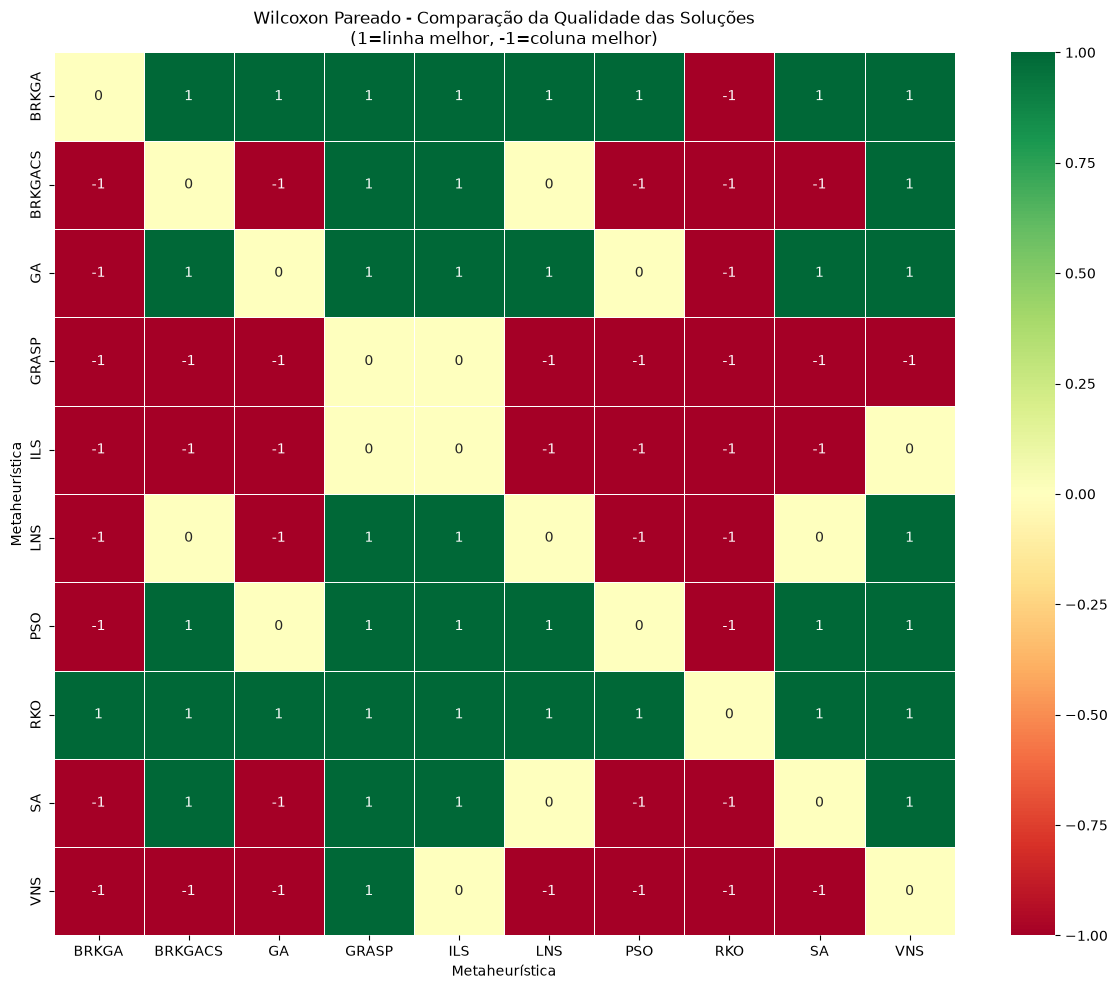

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================================
# LEITURA DOS DADOS
# =====================================================

NOME_DO_ARQUIVO = "result_d2.csv"

try:
    df = pd.read_csv(NOME_DO_ARQUIVO, sep=';')
except:
    df = pd.read_excel(NOME_DO_ARQUIVO)

# =====================================================
# LIMPEZA DOS DADOS
# =====================================================

df.columns = df.columns.str.strip()
df['Metaheuristica'] = df['Metaheuristica'].astype(str).str.strip()
df['Instancia'] = df['Instancia'].astype(str).str.strip()

metaheuristicas = sorted(df['Metaheuristica'].unique())

# =====================================================
# MATRIZES DE RESULTADOS
# =====================================================

n = len(metaheuristicas)

matriz = pd.DataFrame(
    np.zeros((n, n)),
    index=metaheuristicas,
    columns=metaheuristicas
)

matriz_p = pd.DataFrame(
    np.ones((n, n)),
    index=metaheuristicas,
    columns=metaheuristicas
)

# =====================================================
# COMPARAÇÃO TODOS CONTRA TODOS
# MÉTRICA: MELHOR (FUNÇÃO OBJETIVO)
#
# 1  = linha significativamente MELHOR
# -1 = coluna significativamente MELHOR
# 0  = empate estatístico
# =====================================================

for i, mh1 in enumerate(metaheuristicas):

    dados1 = (
        df[df['Metaheuristica'] == mh1]
        .sort_values('Instancia')
    )

    valores1 = dados1['Melhor'].values

    for j, mh2 in enumerate(metaheuristicas):

        if i == j:
            continue

        dados2 = (
            df[df['Metaheuristica'] == mh2]
            .sort_values('Instancia')
        )

        valores2 = dados2['Melhor'].values

        if len(valores1) != len(valores2):
            continue

        try:

            # Teste bicaudal
            _, p_two = wilcoxon(
                valores1,
                valores2,
                alternative='two-sided'
            )

            matriz_p.loc[mh1, mh2] = p_two

            if p_two < 0.05:

                # mh1 melhor que mh2
                _, p_greater = wilcoxon(
                    valores1,
                    valores2,
                    alternative='greater'
                )

                # mh2 melhor que mh1
                _, p_less = wilcoxon(
                    valores1,
                    valores2,
                    alternative='less'
                )

                if p_greater < 0.05:
                    matriz.loc[mh1, mh2] = 1

                elif p_less < 0.05:
                    matriz.loc[mh1, mh2] = -1

                else:
                    matriz.loc[mh1, mh2] = 0

            else:
                matriz.loc[mh1, mh2] = 0

        except ValueError:
            matriz.loc[mh1, mh2] = 0
            matriz_p.loc[mh1, mh2] = np.nan

# =====================================================
# MATRIZ RESULTANTE
# =====================================================

print("\n" + "=" * 70)
print("MATRIZ DE DOMINÂNCIA - QUALIDADE DA SOLUÇÃO")
print("=" * 70)
print("1  = linha possui solução significativamente melhor")
print("-1 = coluna possui solução significativamente melhor")
print("0  = empate estatístico")
print()

print(matriz)

# =====================================================
# SALVAR RESULTADOS
# =====================================================

matriz.to_csv(
    "Matriz_Wilcoxon_Qualidade.csv",
    sep=';',
    encoding='utf-8-sig'
)

matriz_p.to_csv(
    "Matriz_PValores_Wilcoxon.csv",
    sep=';',
    encoding='utf-8-sig'
)

# =====================================================
# CONTAGEM DE VITÓRIAS
# =====================================================

ranking = pd.DataFrame({
    'Metaheuristica': metaheuristicas,
    'Vitorias': (matriz == 1).sum(axis=1),
    'Derrotas': (matriz == -1).sum(axis=1)
})

ranking['Score'] = ranking['Vitorias'] - ranking['Derrotas']

ranking = ranking.sort_values(
    by=['Score', 'Vitorias'],
    ascending=False
)

print("\n" + "=" * 70)
print("RANKING DE DOMINÂNCIA")
print("=" * 70)
print(ranking)

ranking.to_csv(
    "Ranking_Wilcoxon_Qualidade.csv",
    sep=';',
    index=False,
    encoding='utf-8-sig'
)

# =====================================================
# HEATMAP
# =====================================================

plt.figure(figsize=(12, 10))

sns.heatmap(
    matriz,
    annot=True,
    cmap="RdYlGn",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    fmt=".0f"
)

plt.title(
    "Wilcoxon Pareado - Comparação da Qualidade das Soluções\n"
    "(1=linha melhor, -1=coluna melhor)"
)

plt.xlabel("Metaheurística")
plt.ylabel("Metaheurística")

plt.tight_layout()
plt.show()